# CGCNN + Temperature dự đoán TC

Notebook này giữ pipeline đơn giản giống CGCNN mẫu:

`CIF -> crystal graph -> CGCNN -> graph embedding + temperature -> TC`

- Input: graph từ CIF + `Temperature (K)`.
- Output: `TC`.

In [1]:
# !unzip MP_CIF_files.zip

In [2]:
# Cell 1 - Cài thư viện nếu chạy trên Colab
import sys, subprocess, importlib.util

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

if importlib.util.find_spec("ase") is None:
    pip_install("ase")

if importlib.util.find_spec("torch_geometric") is None:
    pip_install("torch-geometric")

print("Done")

Done


In [3]:
# Cell 2 - Import
import os
import re
import glob
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from ase.io import read
from ase.neighborlist import neighbor_list

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
# Cell 3 - Đọc dữ liệu
CSV_PATH = r"C:\Users\Admin\Downloads\20220801_rawdata\AI for materials\mp_cif_matched_data.csv"

df = pd.read_csv(CSV_PATH)

print("CSV_PATH:", CSV_PATH)
print("Shape:", df.shape)
print(df.columns.tolist())
display(df.head())

CSV_PATH: C:\Users\Admin\Downloads\20220801_rawdata\AI for materials\mp_cif_matched_data.csv
Shape: (13047, 10)
['identifier', 'formula', 'atoms', 'num_atoms', 'Formula_original', 'Temperature (K)', 'TC', 'DOI', 'formation_energy_per_atom', 'cif_path']


,identifier,formula,atoms,num_atoms,Formula_original,Temperature (K),TC,DOI,formation_energy_per_atom,cif_path
0,mp-1202900,Al13Fe4,"MSONAtoms(symbols='Al39Fe12', pbc=True, cell=[...",51,Al13Fe4,1.60000,3.514180,10.1103/physrevb.81.184203,-0.32675,downloaded_cif/mp-1202900_Al13Fe4.cif
1,mp-1202900,Al13Fe4,"MSONAtoms(symbols='Al39Fe12', pbc=True, cell=[...",51,Al13Fe4,2.13333,0.678175,10.1103/physrevb.81.184203,-0.32675,downloaded_cif/mp-1202900_Al13Fe4.cif
2,mp-1202900,Al13Fe4,"MSONAtoms(symbols='Al39Fe12', pbc=True, cell=[...",51,Al13Fe4,2.40000,4.377310,10.1103/physrevb.81.184203,-0.32675,downloaded_cif/mp-1202900_Al13Fe4.cif
3,mp-1202900,Al13Fe4,"MSONAtoms(symbols='Al39Fe12', pbc=True, cell=[...",51,Al13Fe4,3.46667,5.487050,10.1103/physrevb.81.184203,-0.32675,downloaded_cif/mp-1202900_Al13Fe4.cif
4,mp-1202900,Al13Fe4,"MSONAtoms(symbols='Al39Fe12', pbc=True, cell=[...",51,Al13Fe4,3.73333,1.787920,10.1103/physrevb.81.184203,-0.32675,downloaded_cif/mp-1202900_Al13Fe4.cif


In [5]:
# Cell 4 - Làm sạch dữ liệu
required_cols = ["identifier", "formula", "Temperature (K)", "TC", "cif_path"]
missing_cols = [c for c in required_cols if c not in df.columns]

if len(missing_cols) > 0:
    raise ValueError(f"Thiếu cột: {missing_cols}")

df = df.dropna(subset=["identifier", "formula", "Temperature (K)", "TC", "cif_path"]).copy()
df["Temperature (K)"] = pd.to_numeric(df["Temperature (K)"], errors="coerce")
df["TC"] = pd.to_numeric(df["TC"], errors="coerce")
df = df.dropna(subset=["Temperature (K)", "TC"]).reset_index(drop=True)

print("After cleaning:", df.shape)
display(df[["identifier", "formula", "Temperature (K)", "TC", "cif_path"]].head())

After cleaning: (13047, 10)


,identifier,formula,Temperature (K),TC,cif_path
0,mp-1202900,Al13Fe4,1.60000,3.514180,downloaded_cif/mp-1202900_Al13Fe4.cif
1,mp-1202900,Al13Fe4,2.13333,0.678175,downloaded_cif/mp-1202900_Al13Fe4.cif
2,mp-1202900,Al13Fe4,2.40000,4.377310,downloaded_cif/mp-1202900_Al13Fe4.cif
3,mp-1202900,Al13Fe4,3.46667,5.487050,downloaded_cif/mp-1202900_Al13Fe4.cif
4,mp-1202900,Al13Fe4,3.73333,1.787920,downloaded_cif/mp-1202900_Al13Fe4.cif


Number of rows: 13047
Number of unique mp-id: 159
Number of unique formula: 159


,Temperature (K),TC
count,13047.000000,13047.000000
mean,350.084553,3.546583
std,274.787281,4.882588
min,0.000703,0.001133
25%,121.548770,0.967655
50%,313.072419,1.710000
75%,500.481129,3.615350
max,1475.680000,28.450600


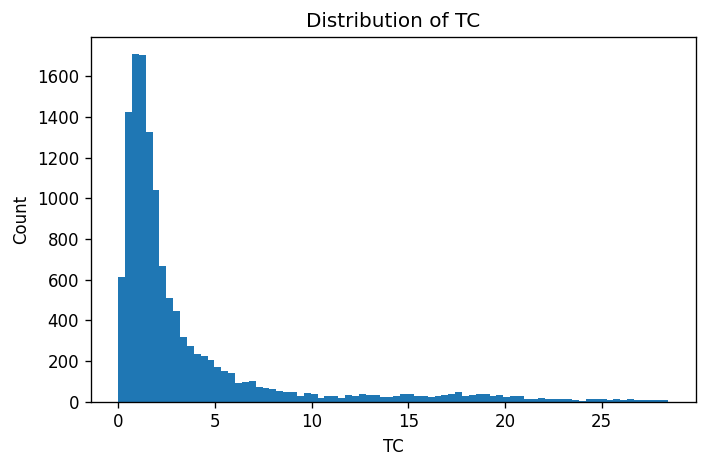

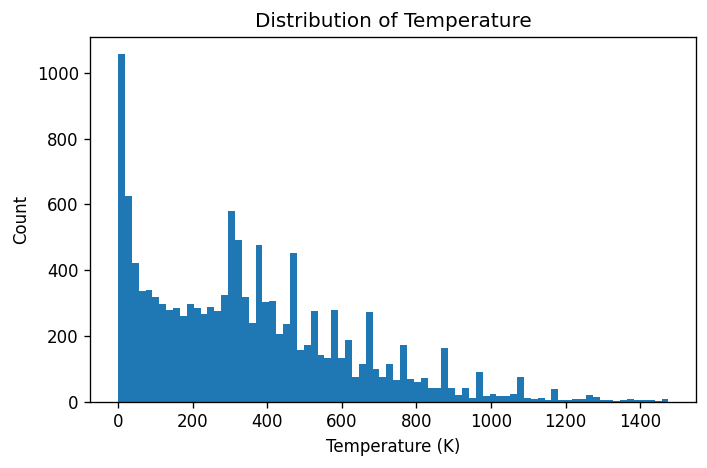

In [6]:
# Cell 5 - Thống kê dữ liệu
print("Number of rows:", len(df))
print("Number of unique mp-id:", df["identifier"].nunique())
print("Number of unique formula:", df["formula"].nunique())

display(df[["Temperature (K)", "TC"]].describe())

plt.figure(figsize=(6,4), dpi=120)
plt.hist(df["TC"], bins=80)
plt.xlabel("TC")
plt.ylabel("Count")
plt.title("Distribution of TC")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4), dpi=120)
plt.hist(df["Temperature (K)"], bins=80)
plt.xlabel("Temperature (K)")
plt.ylabel("Count")
plt.title("Distribution of Temperature")
plt.tight_layout()
plt.show()

In [7]:
# Cell 6 - Tìm đúng file CIF trong folder MP_CIF_files
# Folder của bạn trong Colab: /content/MP_CIF_files
CIF_FOLDER = r"C:\Users\Admin\Downloads\20220801_rawdata\AI for materials\MP_CIF_files"

all_cif_files = glob.glob(os.path.join(CIF_FOLDER, "*.cif"))
mpid_to_cif = {}

for f in all_cif_files:
    name = os.path.basename(f)
    m = re.search(r"mp-\d+", name)
    if m:
        mpid_to_cif[m.group()] = f

print("Số file CIF trong folder:", len(all_cif_files))
print("Số mp-id tìm được trong folder:", len(mpid_to_cif))


def resolve_cif_path(row):
    identifier = str(row["identifier"]).strip()
    cif_path = str(row["cif_path"]).strip()

    # 1. Nếu đường dẫn gốc tồn tại
    candidates = [
        cif_path,
        os.path.join(os.path.dirname(CSV_PATH), cif_path),
        os.path.join("/content", cif_path),
        os.path.join(CIF_FOLDER, os.path.basename(cif_path)),
    ]

    for p in candidates:
        if os.path.exists(p):
            return p

    # 2. Match theo mp-id, không phụ thuộc formula trong tên file
    m = re.search(r"mp-\d+", identifier)
    if m and m.group() in mpid_to_cif:
        return mpid_to_cif[m.group()]

    m = re.search(r"mp-\d+", cif_path)
    if m and m.group() in mpid_to_cif:
        return mpid_to_cif[m.group()]

    return None


df["resolved_cif_path"] = df.apply(resolve_cif_path, axis=1)

n_missing = df["resolved_cif_path"].isna().sum()
print("Total rows:", len(df))
print("Rows with existing CIF:", len(df) - n_missing)
print("Rows missing CIF:", n_missing)

if n_missing > 0:
    missing_unique = df[df["resolved_cif_path"].isna()][["identifier", "formula", "cif_path"]].drop_duplicates()
    print("Missing unique CIF:", len(missing_unique))
    display(missing_unique.head(30))

Số file CIF trong folder: 135
Số mp-id tìm được trong folder: 135
Total rows: 13047
Rows with existing CIF: 12133
Rows missing CIF: 914
Missing unique CIF: 24


,identifier,formula,cif_path
4189,mp-7429,Ca(ZnSb)2,downloaded_cif/mp-7429_Ca(ZnSb)2.cif
7438,mp-1215797,Zn2Cu10Sb4S13,downloaded_cif/mp-1215797_Zn2Cu10Sb4S13.cif
7863,mp-1200177,Cu2SnSe3,downloaded_cif/mp-1200177_Cu2SnSe3.cif
8342,mp-1069042,Eu(ZnSb)2,downloaded_cif/mp-1069042_Eu(ZnSb)2.cif
8351,mp-1193786,Eu11(ZnSb2)6,downloaded_cif/mp-1193786_Eu11(ZnSb2)6.cif
8378,mp-685944,Eu2Zr2O7,downloaded_cif/mp-685944_Eu2Zr2O7.cif
8687,mp-757233,Gd2Zr2O7,downloaded_cif/mp-757233_Gd2Zr2O7.cif
9308,mp-863430,Zn3In2O6,downloaded_cif/mp-863430_Zn3In2O6.cif
9678,mp-4974,La2Zr2O7,downloaded_cif/mp-4974_La2Zr2O7.cif
11121,mp-5977,Nd2Zr2O7,downloaded_cif/mp-5977_Nd2Zr2O7.cif


In [8]:
# Cell 7 - Chỉ giữ các dòng có CIF tồn tại
# Không có CIF thì không thể tạo crystal graph.
df = df[df["resolved_cif_path"].notna()].reset_index(drop=True)

print("Data used for CGCNN:", df.shape)
print("Unique CIF used:", df["identifier"].nunique())

display(df[["identifier", "formula", "Temperature (K)", "TC", "resolved_cif_path"]].head())

if len(df) == 0:
    raise ValueError("Không còn dòng nào có CIF. Kiểm tra lại folder CIF.")

Data used for CGCNN: (12133, 11)
Unique CIF used: 135


,identifier,formula,Temperature (K),TC,resolved_cif_path
0,mp-1202900,Al13Fe4,1.60000,3.514180,C:\Users\Admin\Downloads\20220801_rawdata\AI f...
1,mp-1202900,Al13Fe4,2.13333,0.678175,C:\Users\Admin\Downloads\20220801_rawdata\AI f...
2,mp-1202900,Al13Fe4,2.40000,4.377310,C:\Users\Admin\Downloads\20220801_rawdata\AI f...
3,mp-1202900,Al13Fe4,3.46667,5.487050,C:\Users\Admin\Downloads\20220801_rawdata\AI f...
4,mp-1202900,Al13Fe4,3.73333,1.787920,C:\Users\Admin\Downloads\20220801_rawdata\AI f...


In [9]:
# Cell 8 - Không scale Temperature và TC
# Theo yêu cầu: dùng trực tiếp giá trị thật.
# Input phụ: Temperature (K)
# Output: TC thật

df["temp_input"] = df["Temperature (K)"].astype(float)
df["tc_target"] = df["TC"].astype(float)

display(df[["Temperature (K)", "temp_input", "TC", "tc_target"]].head())

print("Temperature min/max:", df["temp_input"].min(), df["temp_input"].max())
print("TC min/max:", df["tc_target"].min(), df["tc_target"].max())


,Temperature (K),temp_input,TC,tc_target
0,1.60000,1.60000,3.514180,3.514180
1,2.13333,2.13333,0.678175,0.678175
2,2.40000,2.40000,4.377310,4.377310
3,3.46667,3.46667,5.487050,5.487050
4,3.73333,3.73333,1.787920,1.787920


Temperature min/max: 0.00070275 1425.6277001707451
TC min/max: 0.001132696 28.4506


In [10]:
# Cell 9 - Hàm tạo graph từ CIF
# Giữ đúng ý tưởng CGCNN: node = atom, edge = neighbor, edge_length = khoảng cách.

def atoms_to_graph(atoms, r_cut=6.0, max_neighbors=12):
    # Lấy danh sách neighbor từ ASE
    i, j, d = neighbor_list("ijd", atoms, cutoff=r_cut, self_interaction=False)

    if len(i) == 0:
        raise ValueError("Không tìm được neighbor nào trong CIF")

    i = np.asarray(i)
    j = np.asarray(j)
    d = np.asarray(d)

    # Giữ tối đa max_neighbors neighbor gần nhất cho mỗi atom trung tâm
    if max_neighbors is not None:
        keep = []
        for atom_idx in np.unique(i):
            idx = np.where(i == atom_idx)[0]
            idx_sorted = idx[np.argsort(d[idx])]
            keep.extend(idx_sorted[:max_neighbors])

        keep = np.asarray(keep, dtype=int)
        i = i[keep]
        j = j[keep]
        d = d[keep]

    edge_index = torch.tensor(np.vstack([i, j]), dtype=torch.long)
    edge_length = torch.tensor(d, dtype=torch.float32)
    numbers = torch.tensor(atoms.get_atomic_numbers(), dtype=torch.long)

    data = Data(
        numbers=numbers,
        edge_index=edge_index,
        edge_length=edge_length,
        num_nodes=len(numbers),
    )

    return data

In [11]:
# Cell 10 - Build dataset graph
# MAX_ROWS dùng để test nhanh. Khi chạy thật để None.
MAX_ROWS = None

if MAX_ROWS is not None:
    df_work = df.sample(n=min(MAX_ROWS, len(df)), random_state=SEED).reset_index(drop=True)
else:
    df_work = df.copy()

print("Rows used:", len(df_work))

# Cache base graph theo CIF để không đọc lại cùng một CIF quá nhiều lần.
base_graph_cache = {}
data_list = []
failed_rows = []

for k, row in df_work.iterrows():
    try:
        cif_path = row["resolved_cif_path"]

        if cif_path not in base_graph_cache:
            atoms = read(cif_path)
            base_graph_cache[cif_path] = atoms_to_graph(atoms, r_cut=6.0, max_neighbors=12)

        data = base_graph_cache[cif_path].clone()

        # Input phụ: temperature
        data.temperature = torch.tensor([row["Temperature (K)"]], dtype=torch.float32)

        # Output: TC đã scale
        data.y = torch.tensor([row["TC"]], dtype=torch.float32)

        data_list.append(data)

    except Exception as e:
        failed_rows.append((k, row["identifier"], row["formula"], str(e)))

    if (k + 1) % 1000 == 0:
        print(f"Processed {k + 1}/{len(df_work)}")

print("Successful graphs:", len(data_list))
print("Failed rows:", len(failed_rows))
print("Unique base graphs:", len(base_graph_cache))

if len(failed_rows) > 0:
    failed_df = pd.DataFrame(failed_rows, columns=["row", "identifier", "formula", "error"])
    display(failed_df.head(30))

if len(data_list) == 0:
    raise ValueError("Không tạo được graph nào. Kiểm tra lại CIF.")

# Lưu cache graph đã tạo
torch.save(data_list, "cgcnn_tc_graphs_fixed.pt")
print("Saved: cgcnn_tc_graphs_fixed.pt")

Rows used: 12133
Processed 1000/12133
Processed 2000/12133
Processed 3000/12133
Processed 4000/12133
Processed 5000/12133
Processed 6000/12133
Processed 7000/12133
Processed 8000/12133
Processed 9000/12133
Processed 10000/12133
Processed 11000/12133
Processed 12000/12133
Successful graphs: 12133
Failed rows: 0
Unique base graphs: 135
Saved: cgcnn_tc_graphs_fixed.pt


In [12]:
# Cell 11 - Kiểm tra một graph
sample = data_list[0]
print(sample)
print("numbers shape:", sample.numbers.shape)
print("edge_index shape:", sample.edge_index.shape)
print("edge_length shape:", sample.edge_length.shape)
print("temperature:", sample.temperature)
print("target y:", sample.y)

Data(edge_index=[2, 612], numbers=[51], edge_length=[612], num_nodes=51, temperature=[1], y=[1])
numbers shape: torch.Size([51])
edge_index shape: torch.Size([2, 612])
edge_length shape: torch.Size([612])
temperature: tensor([1.6000])
target y: tensor([3.5142])


In [13]:
# Cell 12 - Chia train/validation/test
train_data, temp_data = train_test_split(data_list, test_size=0.2, random_state=SEED)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=SEED)

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

BATCH_SIZE = 64
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))
print(batch)
print("batch.batch shape:", batch.batch.shape)
print("temperature shape:", batch.temperature.shape)
print("y shape:", batch.y.shape)

Train: 9706
Validation: 1213
Test: 1214
DataBatch(edge_index=[2, 19428], numbers=[1619], edge_length=[19428], num_nodes=1619, temperature=[64], y=[64], batch=[1619], ptr=[65])
batch.batch shape: torch.Size([1619])
temperature shape: torch.Size([64])
y shape: torch.Size([64])


In [14]:
# Cell 13 - Hàm aggregate thay cho torch_scatter.scatter
# Không cần cài torch_scatter nữa.

def segment_sum(src, index, dim_size):
    """
    src: [N, F]
    index: [N]
    return: [dim_size, F]
    """
    out = src.new_zeros((dim_size, src.size(1)))
    out.index_add_(0, index, src)
    return out


def segment_mean(src, index, dim_size):
    """
    src: [N, F]
    index: [N]
    return: [dim_size, F]
    """
    out = segment_sum(src, index, dim_size)

    count = src.new_zeros((dim_size,))
    ones = src.new_ones((index.size(0),))
    count.index_add_(0, index, ones)
    count = count.clamp(min=1).view(-1, 1)

    return out / count

In [15]:
# Cell 14 - Gaussian expansion cho edge distance
class GaussianFilter(nn.Module):
    def __init__(self, r_min=0.0, r_max=6.0, num_edge_features=64):
        super().__init__()
        centers = torch.linspace(r_min, r_max, num_edge_features)
        step = (r_max - r_min) / num_edge_features
        self.register_buffer("centers", centers)
        self.register_buffer("step", torch.tensor(step))

    def forward(self, distance):
        distance = distance.view(-1, 1).to(self.centers.device)
        return torch.exp(-0.5 * ((distance - self.centers) / self.step) ** 2)

In [16]:
# Cell 15 - CGCNN layer
class CGCNNConv(nn.Module):
    def __init__(self, atom_fea_len, edge_fea_len):
        super().__init__()
        self.fc_full = nn.Linear(2 * atom_fea_len + edge_fea_len, 2 * atom_fea_len)
        self.bn1 = nn.BatchNorm1d(2 * atom_fea_len)
        self.bn2 = nn.BatchNorm1d(atom_fea_len)

    def forward(self, atom_fea, edge_index, edge_fea):
        center_idx = edge_index[0]
        neigh_idx = edge_index[1]

        atom_center = atom_fea[center_idx]
        atom_neigh = atom_fea[neigh_idx]

        total_fea = torch.cat([atom_center, atom_neigh, edge_fea], dim=1)
        total_gated_fea = self.fc_full(total_fea)
        total_gated_fea = self.bn1(total_gated_fea)

        nbr_filter, nbr_core = total_gated_fea.chunk(2, dim=1)
        nbr_filter = torch.sigmoid(nbr_filter)
        nbr_core = F.softplus(nbr_core)

        message = nbr_filter * nbr_core

        # aggregate message về atom trung tâm
        agg = segment_sum(message, center_idx, dim_size=atom_fea.size(0))
        agg = self.bn2(agg)

        out = F.softplus(atom_fea + agg)
        return out

In [17]:
# Cell 16 - Model CGCNN + Temperature
class CrystalGraphConvNetWithTemp(nn.Module):
    def __init__(
        self,
        orig_atom_fea_len=119,
        atom_fea_len=64,
        edge_fea_len=64,
        n_conv=3,
        h_fea_len=128,
    ):
        super().__init__()

        self.embedding = nn.Embedding(orig_atom_fea_len, atom_fea_len)
        self.gaussian = GaussianFilter(r_min=0.0, r_max=6.0, num_edge_features=edge_fea_len)

        self.convs = nn.ModuleList([
            CGCNNConv(atom_fea_len, edge_fea_len)
            for _ in range(n_conv)
        ])

        # graph embedding + temperature
        self.fc1 = nn.Linear(atom_fea_len + 1, h_fea_len)
        self.fc2 = nn.Linear(h_fea_len, h_fea_len // 2)
        self.fc_out = nn.Linear(h_fea_len // 2, 1)

    def forward(self, batch):
        atom_fea = self.embedding(batch.numbers)
        edge_fea = self.gaussian(batch.edge_length)

        for conv in self.convs:
            atom_fea = conv(atom_fea, batch.edge_index, edge_fea)

        # Pool atom features -> graph feature
        num_graphs = int(batch.batch.max().item()) + 1
        graph_fea = segment_mean(atom_fea, batch.batch, dim_size=num_graphs)

        # Temperature: mỗi graph có 1 giá trị
        temp = batch.temperature.view(-1, 1).to(graph_fea.device)

        # Ghép graph + temperature
        out = torch.cat([graph_fea, temp], dim=1)

        out = F.softplus(self.fc1(out))
        out = F.softplus(self.fc2(out))
        out = self.fc_out(out)

        return out.view(-1)

In [18]:
# Cell 17 - Khởi tạo model
model = CrystalGraphConvNetWithTemp(
    orig_atom_fea_len=119,
    atom_fea_len=64,
    edge_fea_len=64,
    n_conv=3,
    h_fea_len=128,
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

EPOCHS = 1000

history = {
    "train_loss": [],
    "val_loss": []
}

model

CrystalGraphConvNetWithTemp(
  (embedding): Embedding(119, 64)
  (gaussian): GaussianFilter()
  (convs): ModuleList(
    (0-2): 3 x CGCNNConv(
      (fc_full): Linear(in_features=192, out_features=128, bias=True)
      (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (fc1): Linear(in_features=65, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc_out): Linear(in_features=64, out_features=1, bias=True)
)

In [19]:
# Cell 18 - Train/evaluate function

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()
        pred = model(batch)
        y = batch.y.view(-1).to(device)

        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_loss(model, loader):
    model.eval()
    total_loss = 0.0

    for batch in loader:
        batch = batch.to(device)
        pred = model(batch)
        y = batch.y.view(-1).to(device)
        loss = criterion(pred, y)
        total_loss += loss.item() * batch.num_graphs

    return total_loss / len(loader.dataset)

In [20]:
# Cell 19 - Training loop
# Chạy đủ tất cả EPOCHS, không early stopping.

best_val_loss = np.inf
best_epoch = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader)
    val_loss = evaluate_loss(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), "best_cgcnn_tc_temperature_fixed.pt")

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f}"
        )

model.load_state_dict(torch.load("best_cgcnn_tc_temperature_fixed.pt", map_location=device))
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Epoch 001 | Train Loss: 14.811305 | Val Loss: 10.848023
Epoch 005 | Train Loss: 6.131749 | Val Loss: 7.843554
Epoch 010 | Train Loss: 5.410546 | Val Loss: 6.496516
Epoch 015 | Train Loss: 4.977794 | Val Loss: 6.430649
Epoch 020 | Train Loss: 4.842041 | Val Loss: 6.494891
Epoch 025 | Train Loss: 4.553863 | Val Loss: 5.918086
Epoch 030 | Train Loss: 4.387834 | Val Loss: 6.021582
Epoch 035 | Train Loss: 4.345571 | Val Loss: 6.214516
Epoch 040 | Train Loss: 4.284840 | Val Loss: 5.736692
Epoch 045 | Train Loss: 4.262606 | Val Loss: 5.656682
Epoch 050 | Train Loss: 4.350849 | Val Loss: 5.947401
Epoch 055 | Train Loss: 4.222519 | Val Loss: 6.631295
Epoch 060 | Train Loss: 4.268799 | Val Loss: 5.588985
Epoch 065 | Train Loss: 4.075991 | Val Loss: 5.460289
Epoch 070 | Train Loss: 4.065072 | Val Loss: 5.706178
Epoch 075 | Train Loss: 4.026864 | Val Loss: 5.634865
Epoch 080 | Train Loss: 4.021862 | Val Loss: 5.551409
Epoch 085 | Train Loss: 3.961196 | Val Loss: 5.420822
Epoch 090 | Train Loss: 3.

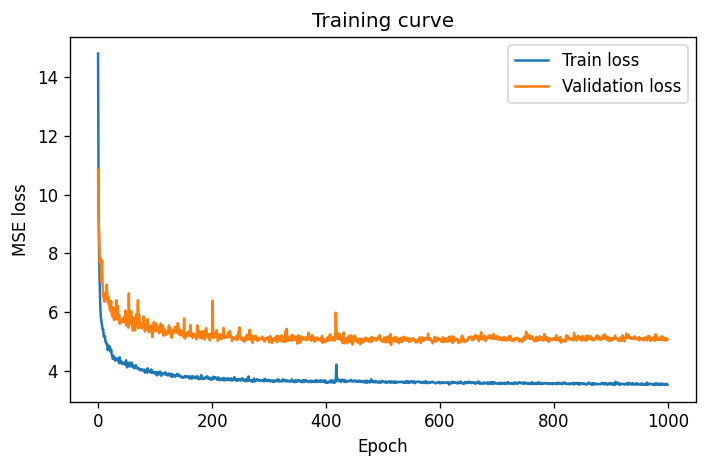

In [21]:
# Cell 20 - Vẽ loss
plt.figure(figsize=(6,4), dpi=120)
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training curve")
plt.legend()
plt.tight_layout()
plt.savefig("cgcnn_loss_curve_fixed.png", dpi=300)
plt.show()

In [22]:
# Cell 21 - Dự đoán trực tiếp TC thật, không inverse scale
@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    preds = []
    targets = []

    for batch in loader:
        batch = batch.to(device)

        pred = model(batch).view(-1)

        preds.extend(pred.detach().cpu().numpy())
        targets.extend(batch.y.view(-1).detach().cpu().numpy())

    y_pred = np.array(preds)
    y_true = np.array(targets)

    # Nếu muốn tránh TC dự đoán âm
    y_pred = np.clip(y_pred, a_min=0, a_max=None)

    return y_true, y_pred


y_true, y_pred = predict_loader(model, test_loader)

r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print(f"Test R2   = {r2:.4f}")
print(f"Test RMSE = {rmse:.4f}")
print(f"Test MAE  = {mae:.4f}")

Test R2   = 0.8824
Test RMSE = 1.6859
Test MAE  = 0.8850


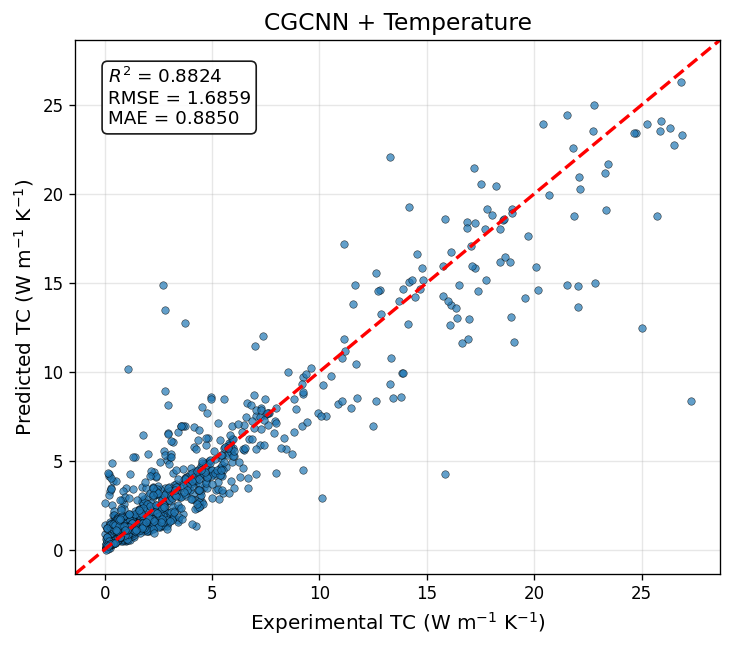

Saved: cgcnn_parity_plot_fixed.png


In [24]:
# Cell 22 - Parity plot CGCNN kèm R2, RMSE và MAE
# Không sử dụng plt.scatter

# Xác định giới hạn chung cho hai trục
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

data_range = max(max_val - min_val, 1e-8)
padding = 0.05 * data_range

plot_min = min_val - padding
plot_max = max_val + padding

# Khởi tạo biểu đồ
fig, ax = plt.subplots(figsize=(6.2, 5.5), dpi=120)

# Vẽ các điểm dự đoán bằng plot()
ax.plot(
    y_true,
    y_pred,
    linestyle='None',
    marker='o',
    markersize=4.5,
    markerfacecolor='#1f77b4',
    markeredgecolor='black',
    markeredgewidth=0.35,
    alpha=0.70
)

# Đường dự đoán lý tưởng y = x
ax.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    color='red',
    linestyle='--',
    linewidth=2
)

# Nội dung metrics
metrics_text = (
    rf'$R^2$ = {r2:.4f}' + '\n'
    rf'RMSE = {rmse:.4f}' + '\n'
    rf'MAE = {mae:.4f}'
)

# Chèn metrics vào góc trên bên trái
ax.text(
    0.05,
    0.95,
    metrics_text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        edgecolor='black',
        alpha=0.90
    )
)

# Đặt cùng giới hạn cho hai trục
ax.set_xlim(plot_min, plot_max)
ax.set_ylim(plot_min, plot_max)

ax.set_xlabel(
    r'Experimental TC (W m$^{-1}$ K$^{-1}$)',
    fontsize=12
)
ax.set_ylabel(
    r'Predicted TC (W m$^{-1}$ K$^{-1}$)',
    fontsize=12
)
ax.set_title('CGCNN + Temperature', fontsize=14)

ax.grid(
    True,
    linestyle='-',
    linewidth=0.8,
    alpha=0.30
)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.savefig(
    'cgcnn_parity_plot_fixed.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print('Saved: cgcnn_parity_plot_fixed.png')

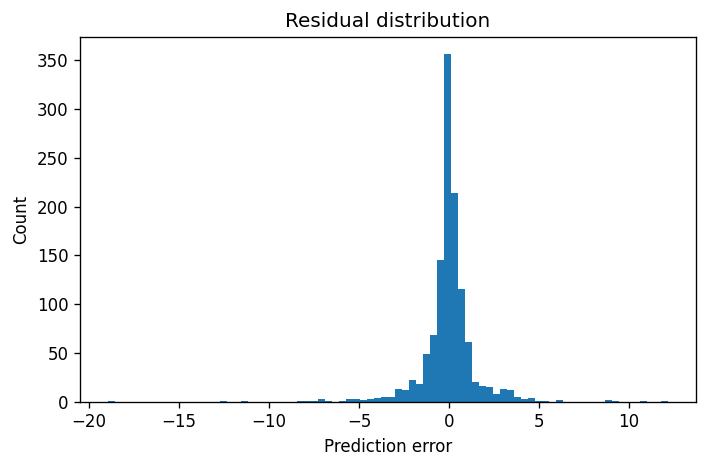

In [25]:
# Cell 23 - Residual plot, không dùng plt.scatter
residuals = y_pred - y_true

plt.figure(figsize=(6,4), dpi=120)
plt.hist(residuals, bins=80)
plt.xlabel("Prediction error")
plt.ylabel("Count")
plt.title("Residual distribution")
plt.tight_layout()
plt.savefig("cgcnn_residual_hist_fixed.png", dpi=300)
plt.show()

In [26]:
# Cell 24 - Lưu kết quả
results = pd.DataFrame({
    "TC_true": y_true,
    "TC_predicted": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

metrics = pd.DataFrame({
    "Model": ["CGCNN + Temperature"],
    "R2": [r2],
    "RMSE": [rmse],
    "MAE": [mae],
})

results.to_csv("CGCNN_TC_test_predictions.csv", index=False)
metrics.to_csv("CGCNN_TC_metrics.csv", index=False)

print("Saved: CGCNN_TC_test_predictions.csv")
print("Saved: CGCNN_TC_metrics.csv")
print("Saved: best_cgcnn_model.pt")

display(metrics)
display(results.head())

Saved: CGCNN_TC_test_predictions.csv
Saved: CGCNN_TC_metrics.csv
Saved: best_cgcnn_model.pt


,Model,R2,RMSE,MAE
0,CGCNN + Temperature,0.882367,1.685899,0.885013


,TC_true,TC_predicted,error,abs_error
0,1.012587,0.489859,-0.522728,0.522728
1,0.999550,1.118559,0.119009,0.119009
2,5.880396,3.847142,-2.033254,2.033254
3,0.850877,0.791921,-0.058956,0.058956
4,1.234295,1.221165,-0.013129,0.013129


**PREDICT TC FOR 2D TEAM DATA**

In [27]:
# ============================================================
# MỘT CELL HOÀN CHỈNH:
# CSV -> MP-ID -> STRUCTURE API THEO BATCH -> GRAPH
# -> LOAD CGCNN -> DỰ ĐOÁN TC TẠI 300 K -> XUẤT CSV
#
# Yêu cầu đã chạy trước đó:
#   1. atoms_to_graph
#   2. CrystalGraphConvNetWithTemp
# ============================================================

# Chỉ bỏ dấu # ở dòng dưới nếu môi trường chưa cài thư viện:
# !pip install -q -U mp-api pymatgen ase torch-geometric

import os
import re
import time
import copy
import warnings
import numpy as np
import pandas as pd
import torch

from mp_api.client import MPRester
from pymatgen.io.ase import AseAtomsAdaptor
from torch_geometric.loader import DataLoader

warnings.filterwarnings("ignore")


# ============================================================
# 1. CẤU HÌNH — CHỈ SỬA PHẦN NÀY
# ============================================================

API_KEY = "Vdjc3ZVzQuDSoF2c5M14BHVWoUV94SS3"

CSV_PATH = r"C:\Users\Admin\Downloads\20220801_rawdata\AI for materials\gnn_basic_columns.csv"
MODEL_PATH = r"C:\Users\Admin\Downloads\20220801_rawdata\AI for materials\best_cgcnn_tc_temperature_fixed.pt"
OUTPUT_PATH = r"CGCNN_TC_predictions_300K.csv"
FAILED_PATH = r"CGCNN_TC_failed_mp_ids.csv"

TEMPERATURE = 300.0

# Phải giống khi train
R_CUT = 6.0
MAX_NEIGHBORS = 12

# API và inference
API_BATCH_SIZE = 100
PREDICT_BATCH_SIZE = 64
MAX_RETRIES = 4
RETRY_WAIT_SECONDS = 5


# ============================================================
# 2. KIỂM TRA ĐẦU VÀO
# ============================================================

if not isinstance(API_KEY, str) or not API_KEY.strip():
    raise ValueError("API_KEY đang trống.")

if API_KEY == "DÁN_API_KEY_MỚI_VÀO_ĐÂY":
    raise ValueError(
        "Hãy thay chuỗi DÁN_API_KEY_MỚI_VÀO_ĐÂY bằng API key thực."
    )

if not os.path.isfile(CSV_PATH):
    raise FileNotFoundError(
        f"Không tìm thấy file CSV:\n{CSV_PATH}"
    )

if not os.path.isfile(MODEL_PATH):
    raise FileNotFoundError(
        f"Không tìm thấy checkpoint model:\n{MODEL_PATH}"
    )

if "atoms_to_graph" not in globals():
    raise NameError(
        "Chưa có hàm atoms_to_graph. "
        "Hãy chạy cell định nghĩa atoms_to_graph trước."
    )

if "CrystalGraphConvNetWithTemp" not in globals():
    raise NameError(
        "Chưa có class CrystalGraphConvNetWithTemp. "
        "Hãy chạy cell định nghĩa model trước."
    )

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ============================================================
# 3. ĐỌC CSV VÀ CHUẨN HÓA MP-ID
# ============================================================

raw_df = pd.read_csv(CSV_PATH)

required_columns = ["identifier", "formula"]

missing_columns = [
    column
    for column in required_columns
    if column not in raw_df.columns
]

if missing_columns:
    raise ValueError(
        f"CSV thiếu cột bắt buộc: {missing_columns}\n"
        f"Các cột hiện có: {raw_df.columns.tolist()}"
    )


def normalize_mp_id(value):
    """
    Trích mã Materials Project dạng mp-12345.

    Hỗ trợ:
      mp-149
      MP-149
      text_mp-149
    """
    if pd.isna(value):
        return None

    match = re.search(
        r"\bmp-\d+\b",
        str(value).strip().lower()
    )

    return match.group(0) if match else None


df = raw_df.copy()

df["source_row"] = np.arange(len(df))
df["identifier_original"] = df["identifier"]

df["identifier"] = (
    df["identifier"]
    .apply(normalize_mp_id)
)

df["formula"] = (
    df["formula"]
    .fillna("")
    .astype(str)
    .str.strip()
)

invalid_df = df[
    df["identifier"].isna()
].copy()

valid_df = (
    df[df["identifier"].notna()]
    .copy()
    .reset_index(drop=True)
)

unique_mp_ids = (
    valid_df["identifier"]
    .drop_duplicates()
    .tolist()
)

print("\nTHỐNG KÊ ĐẦU VÀO")
print("Tổng số dòng CSV:", len(raw_df))
print("Identifier không đúng dạng mp-id:", len(invalid_df))
print("Dòng có mp-id hợp lệ:", len(valid_df))
print("Số mp-id duy nhất:", len(unique_mp_ids))

if len(valid_df) == 0:
    raise ValueError(
        "Không có identifier nào đúng định dạng mp-12345."
    )


# ============================================================
# 4. TẢI STRUCTURE THEO BATCH
# ============================================================

structure_cache = {}
download_errors = []

total_api_batches = (
    len(unique_mp_ids) + API_BATCH_SIZE - 1
) // API_BATCH_SIZE

print(
    f"\nBẮT ĐẦU TẢI {len(unique_mp_ids)} STRUCTURE "
    f"TRONG {total_api_batches} BATCH"
)

with MPRester(API_KEY) as mpr:

    for batch_index, start in enumerate(
        range(0, len(unique_mp_ids), API_BATCH_SIZE),
        start=1
    ):
        batch_ids = unique_mp_ids[
            start:start + API_BATCH_SIZE
        ]

        docs = None
        last_error = None

        for attempt in range(1, MAX_RETRIES + 1):

            try:
                docs = mpr.materials.summary.search(
                    material_ids=batch_ids,
                    fields=[
                        "material_id",
                        "structure"
                    ]
                )

                last_error = None
                break

            except Exception as error:
                last_error = error

                print(
                    f"Batch {batch_index}/{total_api_batches} "
                    f"lỗi ở lần {attempt}/{MAX_RETRIES}: "
                    f"{type(error).__name__}: {error}"
                )

                if attempt < MAX_RETRIES:
                    wait_time = (
                        RETRY_WAIT_SECONDS * attempt
                    )

                    print(
                        f"Chờ {wait_time} giây rồi thử lại..."
                    )

                    time.sleep(wait_time)

        if docs is None:
            for mp_id in batch_ids:
                download_errors.append({
                    "identifier": mp_id,
                    "stage": "api_batch",
                    "error": str(last_error)
                })

            print(
                f"Batch {batch_index}/{total_api_batches}: "
                "thất bại hoàn toàn."
            )

            continue

        returned_ids = set()

        for doc in docs:
            try:
                mp_id = str(doc.material_id)
                returned_ids.add(mp_id)

                structure = getattr(
                    doc,
                    "structure",
                    None
                )

                if structure is not None:
                    structure_cache[mp_id] = structure

            except Exception as error:
                download_errors.append({
                    "identifier": str(
                        getattr(
                            doc,
                            "material_id",
                            "unknown"
                        )
                    ),
                    "stage": "parse_api_document",
                    "error": str(error)
                })

        missing_in_batch = (
            set(batch_ids) - returned_ids
        )

        for mp_id in missing_in_batch:
            download_errors.append({
                "identifier": mp_id,
                "stage": "api_no_result",
                "error": (
                    "Materials Project không trả về "
                    "summary document cho mp-id này"
                )
            })

        print(
            f"Batch {batch_index:02d}/"
            f"{total_api_batches:02d} hoàn thành | "
            f"nhận {len(docs)}/{len(batch_ids)} | "
            f"tổng structure: {len(structure_cache)}"
        )

        # Giảm khả năng chạm rate limit
        time.sleep(0.5)


print("\nHOÀN THÀNH TẢI STRUCTURE")
print(
    f"Nhận được {len(structure_cache)}/"
    f"{len(unique_mp_ids)} structure"
)


# ============================================================
# 5. CHUYỂN STRUCTURE THÀNH CRYSTAL GRAPH
# ============================================================

graph_cache = {}
graph_errors = []

print("\nBẮT ĐẦU TẠO CRYSTAL GRAPH")

for count, mp_id in enumerate(
    unique_mp_ids,
    start=1
):
    structure = structure_cache.get(mp_id)

    if structure is None:
        continue

    try:
        atoms = AseAtomsAdaptor.get_atoms(
            structure
        )

        graph = atoms_to_graph(
            atoms,
            r_cut=R_CUT,
            max_neighbors=MAX_NEIGHBORS
        )

        graph_cache[mp_id] = graph

    except Exception as error:
        graph_errors.append({
            "identifier": mp_id,
            "stage": "atoms_to_graph",
            "error": (
                f"{type(error).__name__}: {error}"
            )
        })

    if count % 100 == 0 or count == len(unique_mp_ids):
        print(
            f"Đã xét {count}/{len(unique_mp_ids)} | "
            f"graph thành công: {len(graph_cache)}"
        )


print("\nHOÀN THÀNH TẠO GRAPH")
print(
    f"Tạo được {len(graph_cache)}/"
    f"{len(unique_mp_ids)} graph"
)


# ============================================================
# 6. TẠO DATASET DỰ ĐOÁN TẠI 300 K
# ============================================================

prediction_graphs = []
prediction_metadata = []
dataset_errors = []

for _, row in valid_df.iterrows():

    mp_id = row["identifier"]

    if mp_id not in graph_cache:
        dataset_errors.append({
            "source_row": int(row["source_row"]),
            "identifier": mp_id,
            "formula": row["formula"],
            "stage": "prepare_prediction",
            "error": "Không có crystal graph hợp lệ"
        })
        continue

    try:
        # Clone để không làm thay đổi graph trong cache
        graph = copy.deepcopy(
            graph_cache[mp_id]
        )

        # Một scalar temperature cho mỗi graph
        graph.temperature = torch.tensor(
            [TEMPERATURE],
            dtype=torch.float32
        )

        prediction_graphs.append(graph)

        prediction_metadata.append({
            "source_row": int(row["source_row"]),
            "identifier": mp_id,
            "formula": row["formula"],
            "Temperature (K)": TEMPERATURE,
            "num_atoms": int(graph.num_nodes)
        })

    except Exception as error:
        dataset_errors.append({
            "source_row": int(row["source_row"]),
            "identifier": mp_id,
            "formula": row["formula"],
            "stage": "clone_graph",
            "error": (
                f"{type(error).__name__}: {error}"
            )
        })


print("\nDATASET DỰ ĐOÁN")
print(
    "Số dòng có graph hợp lệ:",
    len(prediction_graphs)
)
print(
    "Số dòng không có graph:",
    len(dataset_errors)
)

if len(prediction_graphs) == 0:
    all_errors = (
        download_errors
        + graph_errors
        + dataset_errors
    )

    error_df = pd.DataFrame(all_errors)

    if len(invalid_df) > 0:
        invalid_errors = pd.DataFrame({
            "source_row": invalid_df["source_row"],
            "identifier": invalid_df[
                "identifier_original"
            ],
            "formula": invalid_df["formula"],
            "stage": "invalid_identifier",
            "error": (
                "Identifier không đúng dạng mp-12345"
            )
        })

        error_df = pd.concat(
            [error_df, invalid_errors],
            ignore_index=True
        )

    error_df.to_csv(
        FAILED_PATH,
        index=False,
        encoding="utf-8-sig"
    )

    display(error_df.head(30))

    raise ValueError(
        "Không tạo được graph nào. "
        "Đã lưu thông tin lỗi vào FAILED_PATH."
    )


# ============================================================
# 7. LOAD CHECKPOINT VÀ KHỞI TẠO MODEL
# ============================================================

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

if (
    isinstance(checkpoint, dict)
    and "model_state_dict" in checkpoint
):
    state_dict = checkpoint["model_state_dict"]
else:
    state_dict = checkpoint


# Lấy hyperparameter từ checkpoint nếu checkpoint có lưu
checkpoint_params = {}

if isinstance(checkpoint, dict):
    checkpoint_params = (
        checkpoint.get("best_params")
        or checkpoint.get("model_params")
        or checkpoint.get("params")
        or {}
    )


def get_saved_parameter(
    possible_names,
    default_value
):
    for name in possible_names:
        if name in checkpoint_params:
            return checkpoint_params[name]

    return default_value


# Các default này phải giống pipeline train của bạn
model_kwargs = {
    "orig_atom_fea_len": int(
        get_saved_parameter(
            ["orig_atom_fea_len"],
            119
        )
    ),
    "atom_fea_len": int(
        get_saved_parameter(
            ["atom_fea_len", "atom_hidden"],
            64
        )
    ),
    "edge_fea_len": int(
        get_saved_parameter(
            ["edge_fea_len", "edge_hidden"],
            64
        )
    ),
    "n_conv": int(
        get_saved_parameter(
            ["n_conv", "num_conv"],
            3
        )
    ),
    "h_fea_len": int(
        get_saved_parameter(
            ["h_fea_len", "hidden_dim"],
            128
        )
    )
}

print("\nTHAM SỐ KHỞI TẠO MODEL")
print(model_kwargs)

prediction_model = CrystalGraphConvNetWithTemp(
    **model_kwargs
).to(device)

try:
    prediction_model.load_state_dict(
        state_dict,
        strict=True
    )

except RuntimeError as error:
    print(
        "\nKhông load được checkpoint với model_kwargs:",
        model_kwargs
    )

    print(
        "\nLỗi này thường do kiến trúc khởi tạo "
        "khác kiến trúc khi train."
    )

    raise error

prediction_model.eval()

print("Đã load model:", MODEL_PATH)


# ============================================================
# 8. DỰ ĐOÁN TC
# ============================================================

prediction_loader = DataLoader(
    prediction_graphs,
    batch_size=PREDICT_BATCH_SIZE,
    shuffle=False
)

all_predictions = []

print("\nBẮT ĐẦU DỰ ĐOÁN")

with torch.no_grad():

    for batch_index, batch in enumerate(
        prediction_loader,
        start=1
    ):
        batch = batch.to(device)

        output = prediction_model(batch)

        output = output.view(-1)

        all_predictions.extend(
            output.detach().cpu().numpy().tolist()
        )

        if (
            batch_index % 10 == 0
            or batch_index == len(prediction_loader)
        ):
            print(
                f"Batch dự đoán "
                f"{batch_index}/"
                f"{len(prediction_loader)}"
            )


predictions = np.asarray(
    all_predictions,
    dtype=np.float64
)

if len(predictions) != len(prediction_metadata):
    raise RuntimeError(
        "Số prediction không khớp số mẫu:\n"
        f"predictions={len(predictions)}, "
        f"metadata={len(prediction_metadata)}"
    )

if not np.all(np.isfinite(predictions)):
    bad_count = np.sum(
        ~np.isfinite(predictions)
    )

    raise ValueError(
        f"Model sinh ra {bad_count} giá trị NaN/Inf."
    )

# TC vật lý không âm
predictions = np.clip(
    predictions,
    a_min=0.0,
    a_max=None
)


# ============================================================
# 9. LƯU FILE KẾT QUẢ
# ============================================================

result_df = pd.DataFrame(
    prediction_metadata
)

result_df[
    "TC_predicted_300K (W/mK)"
] = predictions

result_df = result_df.sort_values(
    "source_row"
).reset_index(drop=True)

result_df.to_csv(
    OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 10. GỘP VÀ LƯU TẤT CẢ LỖI
# ============================================================

error_frames = []

if len(invalid_df) > 0:
    invalid_error_df = pd.DataFrame({
        "source_row": invalid_df["source_row"],
        "identifier": invalid_df[
            "identifier_original"
        ],
        "formula": invalid_df["formula"],
        "stage": "invalid_identifier",
        "error": (
            "Identifier không đúng dạng mp-12345"
        )
    })

    error_frames.append(invalid_error_df)

for error_list in [
    download_errors,
    graph_errors,
    dataset_errors
]:
    if len(error_list) > 0:
        error_frames.append(
            pd.DataFrame(error_list)
        )

if error_frames:
    failed_df = pd.concat(
        error_frames,
        ignore_index=True,
        sort=False
    )

    failed_df.to_csv(
        FAILED_PATH,
        index=False,
        encoding="utf-8-sig"
    )

else:
    failed_df = pd.DataFrame()


# ============================================================
# 11. HIỂN THỊ KẾT QUẢ
# ============================================================

print("\n" + "=" * 60)
print("HOÀN THÀNH")
print("=" * 60)

print("Tổng dòng đầu vào:", len(raw_df))
print("Structure tải được:", len(structure_cache))
print("Graph tạo được:", len(graph_cache))
print("Số kết quả dự đoán:", len(result_df))
print("Số bản ghi lỗi:", len(failed_df))

print("\nFile kết quả:")
print(OUTPUT_PATH)

if len(failed_df) > 0:
    print("\nFile lỗi:")
    print(FAILED_PATH)

display(result_df.head(20))

if len(failed_df) > 0:
    print("\nMột số lỗi đầu tiên:")
    display(failed_df.head(20))

Device: cuda

THỐNG KÊ ĐẦU VÀO
Tổng số dòng CSV: 2938
Identifier không đúng dạng mp-id: 361
Dòng có mp-id hợp lệ: 2577
Số mp-id duy nhất: 2577

BẮT ĐẦU TẢI 2577 STRUCTURE TRONG 26 BATCH


Retrieving SummaryDoc documents:   0%|          | 0/99 [00:00<?, ?it/s]

Batch 01/26 hoàn thành | nhận 99/100 | tổng structure: 99


Retrieving SummaryDoc documents:   0%|          | 0/94 [00:00<?, ?it/s]

Batch 02/26 hoàn thành | nhận 94/100 | tổng structure: 193


...

Retrieving SummaryDoc documents:   0%|          | 0/77 [00:00<?, ?it/s]

Batch 26/26 hoàn thành | nhận 77/77 | tổng structure: 2242

HOÀN THÀNH TẢI STRUCTURE
Nhận được 2242/2577 structure

BẮT ĐẦU TẠO CRYSTAL GRAPH
Đã xét 100/2577 | graph thành công: 99
Đã xét 300/2577 | graph thành công: 288
Đã xét 400/2577 | graph thành công: 386
Đã xét 500/2577 | graph thành công: 485
Đã xét 600/2577 | graph thành công: 582
Đã xét 700/2577 | graph thành công: 682
Đã xét 800/2577 | graph thành công: 759
Đã xét 900/2577 | graph thành công: 859
Đã xét 1000/2577 | graph thành công: 959
Đã xét 1100/2577 | graph thành công: 1047
Đã xét 1300/2577 | graph thành công: 1230
Đã xét 1400/2577 | graph thành công: 1321
Đã xét 1500/2577 | graph thành công: 1392
Đã xét 1600/2577 | graph thành công: 1490
Đã xét 1700/2577 | graph thành công: 1572
Đã xét 1800/2577 | graph thành công: 1671
Đã xét 1900/2577 | graph thành công: 1764
Đã xét 2000/2577 | graph thành công: 1858
Đã xét 2100/2577 | graph thành công: 1951
Đã xét 2300/2577 | graph thành công: 2017
Đã xét 2577/2577 | graph thành công:

,source_row,identifier,formula,Temperature (K),num_atoms,TC_predicted_300K (W/mK)
0,0,mp-10009,Al2S2,300.0,8,0.669062
1,1,mp-1001082,C4O4Si2,300.0,10,7.660042
2,2,mp-1001825,Be2Li2,300.0,4,11.289361
3,3,mp-10021,In2,300.0,2,33.327126
4,4,mp-1002573,HMnO2,300.0,8,3.783403
5,5,mp-10033,NbS2,300.0,6,3.216149
6,6,mp-1006591,In8Mg4Se16,300.0,28,1.020930
7,7,mp-1006619,O12P2Sn6,300.0,40,5.088694
8,8,mp-1007758,Cd2Hf2,300.0,4,2.789331
9,9,mp-1007824,GaN,300.0,4,18.231617



Một số lỗi đầu tiên:


,source_row,identifier,formula,stage,error
0,2577.0,mvc-10,Nb4O16Ta2Zn4,invalid_identifier,Identifier không đúng dạng mp-12345
1,2578.0,mvc-10030,Bi2Cr2La2O12,invalid_identifier,Identifier không đúng dạng mp-12345
2,2579.0,mvc-10066,Ca2O18Ti8,invalid_identifier,Identifier không đúng dạng mp-12345
3,2580.0,mvc-10067,Mg2O18Ti8,invalid_identifier,Identifier không đúng dạng mp-12345
4,2581.0,mvc-10084,O18Ti8Zn2,invalid_identifier,Identifier không đúng dạng mp-12345
5,2582.0,mvc-10219,O18Sb8Zn2,invalid_identifier,Identifier không đúng dạng mp-12345
6,2583.0,mvc-10249,Mg2O26P6Sb6,invalid_identifier,Identifier không đúng dạng mp-12345
7,2584.0,mvc-1037,BaO8V4,invalid_identifier,Identifier không đúng dạng mp-12345
8,2585.0,mvc-1038,BaCr4O8,invalid_identifier,Identifier không đúng dạng mp-12345
9,2586.0,mvc-1039,BaCo4O8,invalid_identifier,Identifier không đúng dạng mp-12345


In [28]:
# ============================================================
# Lấy 100 vật liệu có TC dự đoán cao nhất
# ============================================================

TOP_N = 100

top100_df = (
    result_df
    .sort_values(
        by="TC_predicted_300K (W/mK)",
        ascending=False
    )
    .head(TOP_N)
    .reset_index(drop=True)
)

OUTPUT_TOP100 = "Top100_TC_predicted_300K.csv"

top100_df.to_csv(
    OUTPUT_TOP100,
    index=False,
    encoding="utf-8-sig"
)

print(f"Đã lưu {len(top100_df)} vật liệu vào:")
print(OUTPUT_TOP100)

display(top100_df)

Đã lưu 100 vật liệu vào:
Top100_TC_predicted_300K.csv


,source_row,identifier,formula,Temperature (K),num_atoms,TC_predicted_300K (W/mK)
0,3,mp-10021,In2,300.0,2,33.327126
1,468,mp-140,B,300.0,1,32.753040
2,437,mp-1243,Ga2O3,300.0,10,27.538155
3,1533,mp-570875,Ga2Os,300.0,6,26.462736
4,1921,mp-715574,Cr2O6,300.0,16,19.595570
...,...,...,...,...,...,...
95,2441,mp-9018,Cd2Li2O8P2,300.0,28,13.145009
96,540,mp-20049,Fe2Li2P2,300.0,6,13.103563
97,1062,mp-31367,Cl2Li2O4,300.0,16,12.975258
98,2080,mp-760595,C4Cu4O12,300.0,20,12.957557


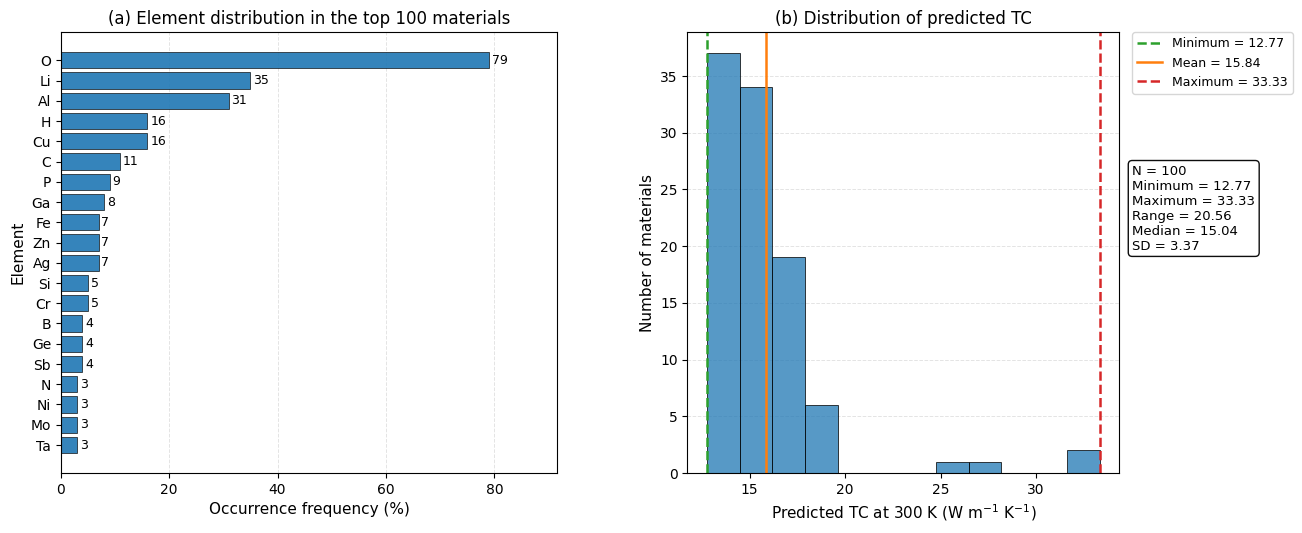

Đã lưu hình: Top100_element_TC_distribution.png
Số vật liệu được phân tích: 100
Số nguyên tố khác nhau: 45
Khoảng TC: 12.7668–33.3271 W/mK
Độ rộng khoảng TC: 20.5603 W/mK
TC trung bình: 15.8416 W/mK
TC trung vị: 15.0420 W/mK

Đã lưu bảng: Top100_element_statistics.csv
Đã lưu bảng: Top100_TC_summary.csv
Đã lưu hình: Top100_element_TC_distribution.png


,Element,Number of materials,Occurrence (%),Mean atomic percent when present (%),Mean predicted TC (W/mK),Maximum predicted TC (W/mK)
0,O,79,79.0,55.341044,15.168278,27.538155
1,Li,35,35.0,20.176849,14.318680,17.769524
2,Al,31,31.0,35.144574,16.173892,17.773777
3,H,16,16.0,32.814834,15.363613,19.383268
4,Cu,16,16.0,19.762356,14.341001,16.937841
5,C,11,11.0,19.380165,14.110774,15.503272
6,P,9,9.0,20.423280,14.276233,17.695509
7,Ga,8,8.0,44.262821,19.887615,27.538155
8,Fe,7,7.0,25.959596,15.256746,17.769524
9,Zn,7,7.0,21.095238,14.605532,17.121922


,Statistic,TC (W/mK)
0,Number of materials,100.000000
1,Minimum,12.766801
2,First quartile,13.920403
3,Median,15.041988
4,Mean,15.841636
5,Third quartile,16.568019
6,Maximum,33.327126
7,Range,20.560325
8,Standard deviation,3.373968


In [31]:
# ============================================================
# PHÂN TÍCH TOP 100 VẬT LIỆU CÓ TC DỰ ĐOÁN CAO NHẤT
# 1. Phân bố nguyên tố
# 2. Khoảng và phân bố TC
# ============================================================

from collections import Counter, defaultdict
from pymatgen.core import Composition

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Cấu hình
# ------------------------------------------------------------

FORMULA_COL = "formula"
TC_COL = "TC_predicted_300K (W/mK)"

# Số nguyên tố thường gặp nhất được thể hiện trên hình
# Đổi thành None nếu muốn vẽ tất cả nguyên tố
N_ELEMENTS_TO_SHOW = 20

ELEMENT_OUTPUT = "Top100_element_statistics.csv"
FIGURE_OUTPUT = "Top100_element_TC_distribution.png"


# ------------------------------------------------------------
# 2. Kiểm tra dữ liệu
# ------------------------------------------------------------

required_columns = [FORMULA_COL, TC_COL]

missing_columns = [
    col for col in required_columns
    if col not in top100_df.columns
]

if missing_columns:
    raise ValueError(
        f"top100_df thiếu các cột: {missing_columns}\n"
        f"Các cột hiện có: {top100_df.columns.tolist()}"
    )

analysis_df = top100_df.copy()

analysis_df[TC_COL] = pd.to_numeric(
    analysis_df[TC_COL],
    errors="coerce"
)

analysis_df = analysis_df.dropna(
    subset=[FORMULA_COL, TC_COL]
).reset_index(drop=True)


# ------------------------------------------------------------
# 3. Phân tích thành phần nguyên tố
# ------------------------------------------------------------

element_occurrence = Counter()
element_tc_values = defaultdict(list)
element_atomic_percent = defaultdict(list)

invalid_formulas = []

for _, row in analysis_df.iterrows():

    formula = str(row[FORMULA_COL]).strip()
    tc_value = float(row[TC_COL])

    try:
        composition = Composition(formula)

        # Thành phần chuẩn hóa, tổng bằng 1
        fraction_dict = (
            composition
            .fractional_composition
            .get_el_amt_dict()
        )

        for element, fraction in fraction_dict.items():

            # Mỗi nguyên tố chỉ được tính một lần trong một vật liệu
            element_occurrence[element] += 1

            # Các giá trị TC của vật liệu chứa nguyên tố
            element_tc_values[element].append(tc_value)

            # Atomic percent của nguyên tố trong vật liệu
            element_atomic_percent[element].append(
                fraction * 100
            )

    except Exception as error:
        invalid_formulas.append({
            "formula": formula,
            "error": str(error)
        })


n_valid = len(analysis_df) - len(invalid_formulas)

if n_valid == 0:
    raise ValueError("Không có công thức hợp lệ để phân tích.")


# ------------------------------------------------------------
# 4. Tạo bảng thống kê nguyên tố
# ------------------------------------------------------------

element_records = []

for element, count in element_occurrence.items():

    element_records.append({
        "Element": element,
        "Number of materials": count,
        "Occurrence (%)": 100 * count / n_valid,
        "Mean atomic percent when present (%)":
            np.mean(element_atomic_percent[element]),
        "Mean predicted TC (W/mK)":
            np.mean(element_tc_values[element]),
        "Maximum predicted TC (W/mK)":
            np.max(element_tc_values[element])
    })

element_stats_df = (
    pd.DataFrame(element_records)
    .sort_values(
        by=["Number of materials", "Mean predicted TC (W/mK)"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

element_stats_df.to_csv(
    ELEMENT_OUTPUT,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 5. Thống kê khoảng TC
# ------------------------------------------------------------

tc_values = analysis_df[TC_COL].to_numpy()

tc_min = np.min(tc_values)
tc_max = np.max(tc_values)
tc_range = tc_max - tc_min
tc_mean = np.mean(tc_values)
tc_median = np.median(tc_values)
tc_std = np.std(tc_values, ddof=1)
tc_q1 = np.percentile(tc_values, 25)
tc_q3 = np.percentile(tc_values, 75)

tc_summary_df = pd.DataFrame({
    "Statistic": [
        "Number of materials",
        "Minimum",
        "First quartile",
        "Median",
        "Mean",
        "Third quartile",
        "Maximum",
        "Range",
        "Standard deviation"
    ],
    "TC (W/mK)": [
        len(tc_values),
        tc_min,
        tc_q1,
        tc_median,
        tc_mean,
        tc_q3,
        tc_max,
        tc_range,
        tc_std
    ]
})

tc_summary_df.to_csv(
    "Top100_TC_summary.csv",
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 6. Chuẩn bị dữ liệu để vẽ
# ------------------------------------------------------------

if N_ELEMENTS_TO_SHOW is None:
    element_plot_df = element_stats_df.copy()
else:
    element_plot_df = element_stats_df.head(
        N_ELEMENTS_TO_SHOW
    ).copy()

# Đảo thứ tự để nguyên tố phổ biến nhất nằm trên cùng
element_plot_df = element_plot_df.iloc[::-1]


# ------------------------------------------------------------
# 7. Vẽ hình
# ------------------------------------------------------------

# ------------------------------------------------------------
# 7. Vẽ hình
# ------------------------------------------------------------

BAR_COLOR = "#1f77b4"

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14.5, 5.8),
    gridspec_kw={"width_ratios": [1.15, 1]}
)

ax1, ax2 = axes


# ----- (a) Phân bố nguyên tố -----

bars = ax1.barh(
    element_plot_df["Element"],
    element_plot_df["Occurrence (%)"],
    color=BAR_COLOR,              # Chỉ sử dụng một màu
    edgecolor="black",
    linewidth=0.5,
    alpha=0.90
)

# Hiển thị số vật liệu ở cuối mỗi cột
for bar, count in zip(
    bars,
    element_plot_df["Number of materials"]
):
    ax1.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count)}",
        va="center",
        ha="left",
        fontsize=9
    )

ax1.set_xlabel("Occurrence frequency (%)", fontsize=11)
ax1.set_ylabel("Element", fontsize=11)
ax1.set_title(
    "(a) Element distribution in the top 100 materials",
    fontsize=12
)

ax1.grid(
    axis="x",
    linestyle="--",
    linewidth=0.7,
    alpha=0.35
)

ax1.set_axisbelow(True)

# Chừa khoảng trống cho số liệu ở cuối cột
ax1.set_xlim(
    0,
    element_plot_df["Occurrence (%)"].max() * 1.16
)


# ----- (b) Phân bố TC -----

ax2.hist(
    tc_values,
    bins=12,
    color=BAR_COLOR,              # Cùng màu với biểu đồ nguyên tố
    edgecolor="black",
    linewidth=0.7,
    alpha=0.75
)

ax2.axvline(
    tc_min,
    color="#2CA02C",
    linestyle="--",
    linewidth=1.8,
    label=f"Minimum = {tc_min:.2f}"
)

ax2.axvline(
    tc_mean,
    color="#FF7F0E",
    linestyle="-",
    linewidth=1.8,
    label=f"Mean = {tc_mean:.2f}"
)

ax2.axvline(
    tc_max,
    color="#D62728",
    linestyle="--",
    linewidth=1.8,
    label=f"Maximum = {tc_max:.2f}"
)

summary_text = (
    f"N = {len(tc_values)}\n"
    f"Minimum = {tc_min:.2f}\n"
    f"Maximum = {tc_max:.2f}\n"
    f"Range = {tc_range:.2f}\n"
    f"Median = {tc_median:.2f}\n"
    f"SD = {tc_std:.2f}"
)

# Đưa chú giải ra ngoài đồ thị
ax2.legend(
    loc="upper left",
    bbox_to_anchor=(1.03, 1.00),
    fontsize=9,
    frameon=True,
    borderaxespad=0
)

# Đưa hộp thống kê ra ngoài đồ thị và xuống dưới chú giải
ax2.text(
    1.03,
    0.70,
    summary_text,
    transform=ax2.transAxes,
    ha="left",
    va="top",
    fontsize=9.5,
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        edgecolor="black",
        alpha=0.95
    )
)

ax2.set_xlabel(
    r"Predicted TC at 300 K (W m$^{-1}$ K$^{-1}$)",
    fontsize=11
)
ax2.set_ylabel("Number of materials", fontsize=11)
ax2.set_title(
    "(b) Distribution of predicted TC",
    fontsize=12
)

ax2.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.35
)

ax2.set_axisbelow(True)

# Chừa vùng bên phải cho chú giải và hộp thống kê
fig.subplots_adjust(
    left=0.07,
    right=0.80,
    bottom=0.14,
    top=0.90,
    wspace=0.28
)

plt.savefig(
    FIGURE_OUTPUT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Đã lưu hình: {FIGURE_OUTPUT}")

# ------------------------------------------------------------
# 8. Hiển thị kết quả
# ------------------------------------------------------------

print(f"Số vật liệu được phân tích: {n_valid}")
print(f"Số nguyên tố khác nhau: {len(element_stats_df)}")
print(f"Khoảng TC: {tc_min:.4f}–{tc_max:.4f} W/mK")
print(f"Độ rộng khoảng TC: {tc_range:.4f} W/mK")
print(f"TC trung bình: {tc_mean:.4f} W/mK")
print(f"TC trung vị: {tc_median:.4f} W/mK")

if invalid_formulas:
    print(
        f"Có {len(invalid_formulas)} công thức "
        "không thể phân tích."
    )
    display(pd.DataFrame(invalid_formulas))

print(f"\nĐã lưu bảng: {ELEMENT_OUTPUT}")
print("Đã lưu bảng: Top100_TC_summary.csv")
print(f"Đã lưu hình: {FIGURE_OUTPUT}")

display(element_stats_df)
display(tc_summary_df)